# Model Training & Evaluation

Train a Numba-jitted Linear State-Space Model (LSSM) that maps EMG -> joint angles using the preprocessed `df_model` written by `data_preprocess.ipynb`.

Stages:
1. Config + imports
2. Load preprocessed training data
3. Feature setup (optional PCA on EMG / joints)
4. LSSM model definition
5. Train
6. Evaluation: metrics, dynamics, prediction plots, FK arm animation

## 1. Config & imports

In [23]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arm_inverse_kinematics import forward_kinematics_fixed, L1_FIXED, L2_FIXED
from arm_visualizer import ArmVisualizer

# ---------------- Config ----------------
TRAINING_DATA_DIR   = 'training_data'
TRAINING_DATA_FILE  = None     # None -> pick most-recent CSV in TRAINING_DATA_DIR

# Feature setup
USE_PCA_EMG         = False    # if True, reduce EMG -> N components
USE_PCA_JOINT       = False    # if True, reduce joints -> N components
N_PCA_EMG           = 2
N_PCA_JOINT         = 2
JOINT_TARGETS       = ['q4']   # which joint columns to predict when not using PCA

# Model
STATE_DIM           = 1
N_RESTARTS          = 10
N_POLISH            = 3
N_BURNIN            = 0
L2_ALPHA            = 1e-5
STANDARDIZE         = True
LEARN_X0            = True
SEED                = 42

# Evaluation
EMG_SAMPLE_RATE_HZ  = 160       # used for FFT freq axis
VIZ_DOWNSAMPLE_N    = 600       # frames for the 3D arm animation

## 2. Load preprocessed training data

In [24]:
if TRAINING_DATA_FILE is None:
    candidates = sorted(glob.glob(os.path.join(TRAINING_DATA_DIR, 'training_data_*.csv')))
    if not candidates:
        raise FileNotFoundError(f'No training_data_*.csv files in {TRAINING_DATA_DIR}/')
    training_data_path = candidates[-1]
else:
    training_data_path = os.path.join(TRAINING_DATA_DIR, TRAINING_DATA_FILE)

print(f'Loading: {training_data_path}')
df_model = pd.read_csv(training_data_path)

emg_cols   = [c for c in df_model.columns if c not in ['time', 'q1', 'q2', 'q3', 'q4']]
joint_cols_all = ['q1', 'q2', 'q3', 'q4']

print(f'df_model shape: {df_model.shape}')
print(f'EMG channels  : {emg_cols}')
print(f'Joint cols    : {joint_cols_all}')
df_model.head()

Loading: training_data/training_data_20260425_013519.csv
df_model shape: (2707, 7)
EMG channels  : ['Channel 3', 'Channel 4']
Joint cols    : ['q1', 'q2', 'q3', 'q4']


,time,Channel 3,Channel 4,q1,q2,q3,q4
0,0.612944,0.039802,-0.056199,1.216329,1.917091,-1.852984,1.667854
1,0.619553,0.030521,-0.044906,1.216017,1.910577,-1.845170,1.670733
2,0.626163,0.022872,-0.035997,1.215704,1.904062,-1.837355,1.673613
3,0.632772,0.016793,-0.029443,1.215391,1.897547,-1.829540,1.676492
4,0.639382,0.012216,-0.025199,1.215079,1.891033,-1.821725,1.679372


## 3. Feature setup (optional PCA)

Build `U` (inputs, EMG-derived) and `Z` (targets, joint-derived).
PCA is off by default — the model learns directly from EMG channels to the chosen joint targets.

In [25]:
from sklearn.decomposition import PCA

emg_data         = df_model[emg_cols].values
full_joint_data  = df_model[joint_cols_all].values

# --- EMG side ---
if USE_PCA_EMG:
    pca_emg = PCA(n_components=N_PCA_EMG)
    U = pca_emg.fit_transform(emg_data)
    print(f'EMG PCA: {emg_data.shape[1]} channels -> {N_PCA_EMG} components')
    print(f'  Explained variance ratio: {pca_emg.explained_variance_ratio_}')
    print(f'  Cumulative              : {pca_emg.explained_variance_ratio_.sum():.4f}')
else:
    pca_emg = None
    U = emg_data
    print(f'EMG PCA disabled. U shape: {U.shape}')

# --- Joint side ---
if USE_PCA_JOINT:
    pca_joint = PCA(n_components=N_PCA_JOINT)
    Z = pca_joint.fit_transform(full_joint_data)
    print(f'Joint PCA: 4 joints -> {N_PCA_JOINT} components')
    print(f'  Explained variance ratio: {pca_joint.explained_variance_ratio_}')
else:
    pca_joint = None
    Z = df_model[JOINT_TARGETS].values
    print(f'Joint PCA disabled. Predicting columns: {JOINT_TARGETS}  (Z shape: {Z.shape})')

print(f'\nU range: [{U.min():.3f}, {U.max():.3f}]  std per col: {U.std(axis=0).round(3)}')
print(f'Z range: [{Z.min():.3f}, {Z.max():.3f}]  std per col: {Z.std(axis=0).round(3)}')

EMG PCA disabled. U shape: (2707, 2)
Joint PCA disabled. Predicting columns: ['q4']  (Z shape: (2707, 1))

U range: [-2.661, 2.694]  std per col: [1. 1.]
Z range: [1.195, 2.241]  std per col: [0.23]


## 4. LSSM model definition

Linear state-space model

$$x_{k+1} = A x_k + B u_k, \quad z_k = C x_k$$

Fit by prediction-error minimization with Numba-jitted forward/backward passes and analytic gradients via reverse-mode through the recursion. L-BFGS-B with multi-restart + polish.

In [26]:
"""
Linear State-Space Model with Numba-jitted forward and backward passes.

Model:
    x_{k+1} = A x_k + B u_k
    z_k     = C x_k

Fit by prediction-error minimization with x_0 = 0 (or learned), using a
hand-derived analytic gradient (reverse-mode through the recursion).
"""
import numpy as np
from numba import njit
from scipy.optimize import minimize


@njit
def _forward(U, A, B, C, x0):
    T = U.shape[0]
    p = C.shape[0]
    d = A.shape[0]
    m = U.shape[1]
    X = np.empty((T, d))
    Z_hat = np.empty((T, p))
    x = x0.copy()
    for k in range(T):
        for i in range(d):
            X[k, i] = x[i]
        for i in range(p):
            s = 0.0
            for j in range(d):
                s += C[i, j] * x[j]
            Z_hat[k, i] = s
        x_new = np.zeros(d)
        for i in range(d):
            s = 0.0
            for j in range(d):
                s += A[i, j] * x[j]
            for j in range(m):
                s += B[i, j] * U[k, j]
            x_new[i] = s
        x = x_new
    return X, Z_hat


@njit
def _backward_accumulate(U, Z, X, Z_hat, A, C, dA, dB, dC, dx0,
                         n_burnin, total_count):
    T = U.shape[0]
    p = C.shape[0]
    d = A.shape[0]
    m = U.shape[1]
    scale = 2.0 / total_count

    R = np.empty((T, p))
    sse = 0.0
    for k in range(T):
        if k < n_burnin:
            for i in range(p):
                R[k, i] = 0.0
        else:
            for i in range(p):
                r = Z_hat[k, i] - Z[k, i]
                R[k, i] = r
                sse += r * r

    for k in range(T):
        for i in range(p):
            for j in range(d):
                dC[i, j] += scale * R[k, i] * X[k, j]

    lam = np.zeros(d)
    for k in range(T - 1, -1, -1):
        if k < T - 1:
            for i in range(d):
                for j in range(d):
                    dA[i, j] += lam[i] * X[k, j]
                for j in range(m):
                    dB[i, j] += lam[i] * U[k, j]
        new_lam = np.zeros(d)
        for i in range(d):
            s = 0.0
            for j in range(p):
                s += C[j, i] * R[k, j]
            new_lam[i] = scale * s
            for j in range(d):
                new_lam[i] += A[j, i] * lam[j]
        lam = new_lam

    for i in range(d):
        dx0[i] += lam[i]

    return sse


@njit
def _step(x, u, A, B, C):
    """Single-step inference: returns (z_k, x_{k+1})."""
    d = A.shape[0]
    p = C.shape[0]
    m = u.shape[0]
    z = np.zeros(p)
    for i in range(p):
        s = 0.0
        for j in range(d):
            s += C[i, j] * x[j]
        z[i] = s
    x_next = np.zeros(d)
    for i in range(d):
        s = 0.0
        for j in range(d):
            s += A[i, j] * x[j]
        for j in range(m):
            s += B[i, j] * u[j]
        x_next[i] = s
    return z, x_next


class LSSM:
    """Linear state-space model fit by prediction-error minimization with analytic gradients."""

    def __init__(self, state_dim, input_dim, output_dim):
        self.d = state_dim
        self.m = input_dim
        self.p = output_dim
        self.A = np.zeros((self.d, self.d))
        self.B = np.zeros((self.d, self.m))
        self.C = np.zeros((self.p, self.d))
        self.x0_learned = np.zeros(self.d)
        self.x = np.zeros(self.d)
        self.u_mean = np.zeros(self.m)
        self.u_std = np.ones(self.m)
        self.z_mean = np.zeros(self.p)
        self.z_std = np.ones(self.p)

    def _init_theta(self, rng, learn_x0):
        """A as block-diag 2x2 rotation-scaling blocks (mix of slow + fast modes); B, C small."""
        d, m, p = self.d, self.m, self.p
        A0 = np.zeros((d, d))
        n_blocks = d // 2
        if n_blocks > 0:
            omegas = np.exp(np.linspace(np.log(2*np.pi/2000),
                                        np.log(2*np.pi/8), n_blocks))
            radii = rng.uniform(0.85, 0.98, size=n_blocks)
            for i, (om, r) in enumerate(zip(omegas, radii)):
                c, s = r*np.cos(om), r*np.sin(om)
                A0[2*i, 2*i] = c
                A0[2*i, 2*i+1] = -s
                A0[2*i+1, 2*i] = s
                A0[2*i+1, 2*i+1] = c
        if d % 2 == 1:
            A0[-1, -1] = rng.uniform(0.85, 0.98)
        A0 += 0.01 * rng.standard_normal((d, d))

        B0 = 0.1 * rng.standard_normal((d, m))
        C0 = (0.1 / np.sqrt(d)) * rng.standard_normal((p, d))

        parts = [A0.ravel(), B0.ravel(), C0.ravel()]
        if learn_x0:
            parts.append(np.zeros(d))
        return np.concatenate(parts)

    def reset(self):
        """Zero the running latent state. Call between independent episodes."""
        self.x = self.x0_learned.copy()

    def __call__(self, u, advance=True):
        u = np.ascontiguousarray(np.asarray(u, dtype=np.float64).reshape(self.m))
        u_norm = (u - self.u_mean) / self.u_std
        z, x_next = _step(self.x, u_norm, self.A, self.B, self.C)
        if advance:
            self.x = x_next
        return z * self.z_std + self.z_mean

    def predict(self, U):
        U = np.ascontiguousarray(np.asarray(U, dtype=np.float64))
        U_norm = (U - self.u_mean) / self.u_std
        _, Z_hat = _forward(U_norm, self.A, self.B, self.C, self.x0_learned)
        return Z_hat * self.z_std + self.z_mean

    def fit(self, U, Z, n_restarts=1, seed=0,
            n_burnin=0, alpha=0.0, learn_x0=True, standardize=True, n_polish=3):
        """
        U, Z: either single arrays (T, m), (T, p), or lists of episode arrays.
        n_burnin: number of initial timesteps per episode excluded from loss.
        alpha: L2 regularization on A, B, C (not on x0).
        learn_x0: if True, x0 is a learnable parameter shared across episodes.
        """
        if isinstance(U, np.ndarray) and U.ndim == 2:
            U_eps = [np.ascontiguousarray(U, dtype=np.float64)]
            Z_eps = [np.ascontiguousarray(Z, dtype=np.float64)]
        else:
            U_eps = [np.ascontiguousarray(np.asarray(u, dtype=np.float64)) for u in U]
            Z_eps = [np.ascontiguousarray(np.asarray(z, dtype=np.float64)) for z in Z]

        if standardize:
            U_all = np.concatenate(U_eps)
            Z_all = np.concatenate(Z_eps)
            self.u_mean = U_all.mean(axis=0)
            self.u_std = U_all.std(axis=0) + 1e-8
            self.z_mean = Z_all.mean(axis=0)
            self.z_std = Z_all.std(axis=0) + 1e-8
            U_eps = [(u - self.u_mean) / self.u_std for u in U_eps]
            Z_eps = [(z - self.z_mean) / self.z_std for z in Z_eps]

        d, m, p = self.d, self.m, self.p
        nA, nB, nC, nx0 = d*d, d*m, p*d, (d if learn_x0 else 0)

        total_count = sum(max(0, u.shape[0] - n_burnin) for u in U_eps) * p
        if total_count == 0:
            raise ValueError("n_burnin >= episode lengths; nothing to score.")

        def loss_and_grad(theta):
            A = np.ascontiguousarray(theta[:nA].reshape(d, d))
            B = np.ascontiguousarray(theta[nA:nA+nB].reshape(d, m))
            C = np.ascontiguousarray(theta[nA+nB:nA+nB+nC].reshape(p, d))
            x0 = np.ascontiguousarray(theta[nA+nB+nC:]) if learn_x0 else np.zeros(d)

            dA = np.zeros((d, d)); dB = np.zeros((d, m))
            dC = np.zeros((p, d)); dx0 = np.zeros(d)
            sse = 0.0
            for U_e, Z_e in zip(U_eps, Z_eps):
                X, Z_hat = _forward(U_e, A, B, C, x0)
                sse += _backward_accumulate(U_e, Z_e, X, Z_hat, A, C,
                                            dA, dB, dC, dx0,
                                            n_burnin, total_count)
            loss = sse / total_count

            if alpha > 0.0:
                loss += alpha * (np.sum(A*A) + np.sum(B*B) + np.sum(C*C))
                dA += 2.0 * alpha * A
                dB += 2.0 * alpha * B
                dC += 2.0 * alpha * C

            if learn_x0:
                grad = np.concatenate([dA.ravel(), dB.ravel(), dC.ravel(), dx0])
            else:
                grad = np.concatenate([dA.ravel(), dB.ravel(), dC.ravel()])

            if not np.isfinite(loss) or not np.all(np.isfinite(grad)):
                return 1e10, np.zeros_like(grad)
            return loss, grad

        rng = np.random.default_rng(seed)

        # Stage 1: cheap exploration of all restarts
        candidates = []
        for _ in range(n_restarts):
            theta0 = self._init_theta(rng, learn_x0)
            res = minimize(loss_and_grad, theta0, jac=True, method='L-BFGS-B',
                           options={'maxiter': 100, 'ftol': 1e-6, 'gtol': 1e-4})
            if res.x is not None:
                final_loss, _ = loss_and_grad(res.x)
                if np.isfinite(final_loss):
                    candidates.append((final_loss, res.x))

        if not candidates:
            best_theta = self._init_theta(rng, learn_x0)
            print('Warning: no stage-1 candidate succeeded; using random init.')
        else:
            candidates.sort(key=lambda c: c[0])
            k = min(n_polish, len(candidates))
            print(f'Stage 1 top-{k} losses: {[f"{c[0]:.6f}" for c in candidates[:k]]}')

            # Stage 2: polish the top k
            best_loss = np.inf
            best_theta = candidates[0][1]
            for i in range(k):
                _, theta_i = candidates[i]
                res = minimize(loss_and_grad, theta_i, jac=True, method='L-BFGS-B',
                               options={'maxiter': 2000, 'ftol': 1e-10, 'gtol': 1e-8})
                if res.x is not None:
                    final_loss, _ = loss_and_grad(res.x)
                    tag = '(new best)' if final_loss < best_loss else ''
                    print(f'  Polish {i+1}/{k}: {final_loss:.6f} {tag}')
                    if final_loss < best_loss:
                        best_loss = final_loss
                        best_theta = res.x

        self.A = np.ascontiguousarray(best_theta[:nA].reshape(d, d))
        self.B = np.ascontiguousarray(best_theta[nA:nA+nB].reshape(d, m))
        self.C = np.ascontiguousarray(best_theta[nA+nB:nA+nB+nC].reshape(p, d))
        self.x0_learned = (np.ascontiguousarray(best_theta[nA+nB+nC:])
                           if learn_x0 else np.zeros(d))
        self.reset()
        return self


## 5. Train

In [27]:
model = LSSM(state_dim=STATE_DIM, input_dim=U.shape[1], output_dim=Z.shape[1])
model.fit(U, Z,
          n_restarts=N_RESTARTS,
          n_polish=N_POLISH,
          n_burnin=N_BURNIN,
          alpha=L2_ALPHA,
          learn_x0=LEARN_X0,
          standardize=STANDARDIZE,
          seed=SEED)

Z_hat = model.predict(U)
mse = np.mean((Z_hat - Z) ** 2)
print(f'\nTraining MSE: {mse:.6f}')

Stage 1 top-3 losses: ['0.881107', '0.881151', '0.881169']
  Polish 1/3: 0.881107 (new best)
  Polish 2/3: 0.868069 (new best)
  Polish 3/3: 0.881169 

Training MSE: 0.045811


## 6. Evaluation

### 6a. Learned dynamics — eigenvalues, singular values, hidden-state activity

In [28]:
eigs = np.linalg.eigvals(model.A)
print('A eigenvalue magnitudes (top 5):', sorted(np.abs(eigs), reverse=True)[:5])
print('A eigenvalue angles    (top 5):', sorted([abs(np.angle(e)) for e in eigs], reverse=True)[:5])
periods = [2*np.pi/abs(np.angle(e)) for e in eigs if abs(np.angle(e)) > 1e-3]
print('Eigenmode periods (samples, top 5):', sorted(periods, reverse=True)[:5])

print('\nA singular values:', np.linalg.svd(model.A, compute_uv=False))
print('B singular values:', np.linalg.svd(model.B, compute_uv=False))
print('C singular values:', np.linalg.svd(model.C, compute_uv=False))

X, _ = _forward((U - model.u_mean) / model.u_std,
                model.A, model.B, model.C, model.x0_learned)
print('\nHidden state std dev over time:')
for i in range(model.d):
    print(f'  x[{i}] std: {np.std(X[:, i]):.4f}')

A eigenvalue magnitudes (top 5): [np.float64(0.9946967417987147)]
A eigenvalue angles    (top 5): [np.float64(0.0)]
Eigenmode periods (samples, top 5): []

A singular values: [0.99469674]
B singular values: [0.20246196]
C singular values: [0.42781903]



Hidden state std dev over time:
  x[0] std: 0.8480


### 6b. Prediction plots — true vs predicted targets

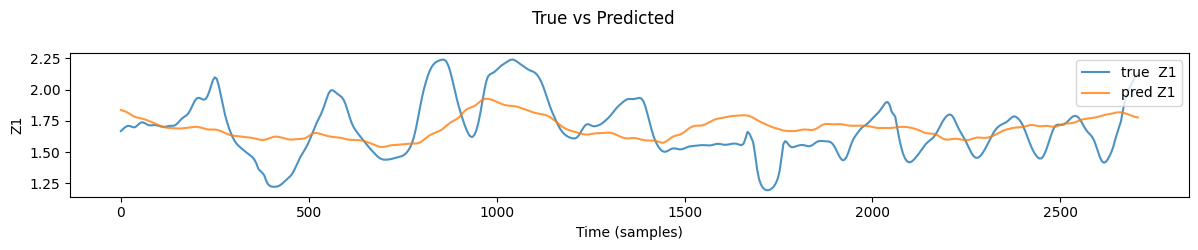

In [29]:
plt.close('all')
n_out = Z.shape[1]
fig, ax = plt.subplots(n_out, 1, figsize=(12, 2.5*n_out), sharex=True)
if n_out == 1:
    ax = [ax]
for i in range(n_out):
    ax[i].plot(Z[:, i],     label=f'true  Z{i+1}', alpha=0.8)
    ax[i].plot(Z_hat[:, i], label=f'pred Z{i+1}', alpha=0.8)
    ax[i].set_ylabel(f'Z{i+1}')
    ax[i].legend(loc='upper right')
ax[-1].set_xlabel('Time (samples)')
plt.suptitle('True vs Predicted')
plt.tight_layout()
plt.show()

### 6c. Input/output cross-correlation (lag analysis)

In [30]:
from scipy.signal import correlate
from scipy.stats import pearsonr

print('Pearson correlations (per-channel):')
for i in range(min(U.shape[1], 4)):
    for j in range(Z.shape[1]):
        r, p = pearsonr(U[:, i], Z[:, j])
        print(f'  U{i+1} vs Z{j+1}: r={r:+.4f}  (p={p:.4f})')

print('\nCross-correlation peak lags:')
for i in range(min(U.shape[1], 4)):
    for j in range(Z.shape[1]):
        x = U[:, i] - U[:, i].mean()
        y = Z[:, j] - Z[:, j].mean()
        c = correlate(y, x, mode='full') / (np.std(x)*np.std(y)*len(x))
        lags = np.arange(-len(x)+1, len(x))
        peak_idx = np.argmax(np.abs(c))
        print(f'  U{i+1}->Z{j+1}: peak corr {c[peak_idx]:+.3f} at lag {lags[peak_idx]} samples')

Pearson correlations (per-channel):
  U1 vs Z1: r=+0.0675  (p=0.0004)
  U2 vs Z1: r=-0.0605  (p=0.0016)

Cross-correlation peak lags:
  U1->Z1: peak corr -0.396 at lag -1128 samples
  U2->Z1: peak corr +0.392 at lag -1128 samples


### 6d. Inverse PCA -> joint angles, then FK arm animation

If joint PCA was used, invert it back to (q1..q4). Otherwise we predicted joint columns directly; the remaining joints are filled in from ground truth so the FK animation has all four angles.

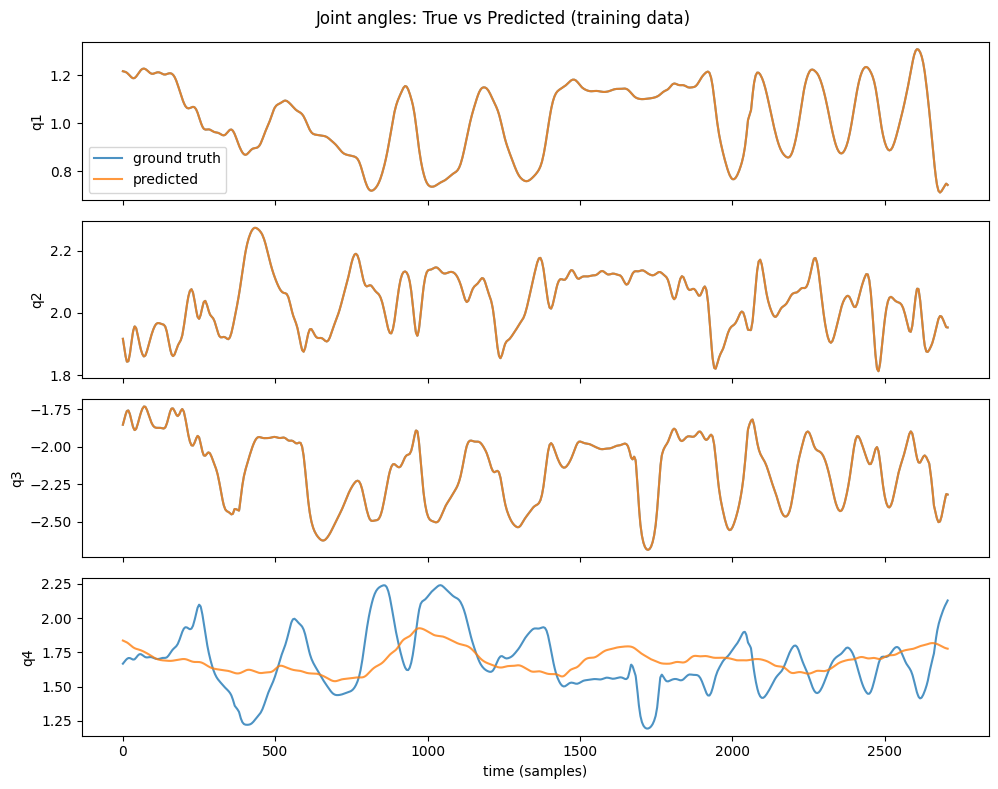

In [31]:
# Reconstruct full (q1..q4) from predictions
if USE_PCA_JOINT:
    q_hat_full = pca_joint.inverse_transform(Z_hat)
else:
    # Predictions only cover JOINT_TARGETS; copy ground truth for the rest.
    q_hat_full = full_joint_data.copy()
    for k, col in enumerate(JOINT_TARGETS):
        col_idx = joint_cols_all.index(col)
        q_hat_full[:, col_idx] = Z_hat[:, k]

q_gt_full = full_joint_data

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
for i, col in enumerate(joint_cols_all):
    ax[i].plot(q_gt_full[:, i],  label='ground truth', alpha=0.8)
    ax[i].plot(q_hat_full[:, i], label='predicted',    alpha=0.8)
    ax[i].set_ylabel(col)
ax[0].legend()
ax[-1].set_xlabel('time (samples)')
plt.suptitle('Joint angles: True vs Predicted (training data)')
plt.tight_layout()
plt.show()

In [33]:
# 3D arm animation: ground truth vs EMG-reconstructed
T_full = q_hat_full.shape[0]
T_viz  = min(VIZ_DOWNSAMPLE_N, T_full)
step   = max(1, T_full // T_viz)
idx    = np.arange(0, T_full, step)[:T_viz]

q_gt_ds  = q_gt_full[idx]
q_hat_ds = q_hat_full[idx]
times    = df_model['time'].values[idx]

viz = ArmVisualizer(fk_func=forward_kinematics_fixed, L1=L1_FIXED, L2=L2_FIXED)
viz.add_arm(name='Ground truth', color='green', dash='dash',
            q1=q_gt_ds[:, 0], q2=q_gt_ds[:, 1], q3=q_gt_ds[:, 2], q4=q_gt_ds[:, 3])
viz.add_arm(name='EMG-Reconstructed', color='yellow',
            q1=q_hat_ds[:, 0], q2=q_hat_ds[:, 1], q3=q_hat_ds[:, 2], q4=q_hat_ds[:, 3])
viz.show(times=times)